Attempting to load data from: ..\Data\Processed\Cleaned_IEF_Shipments_FY26.csv

 PART 1: COMPREHENSIVE EDA 

=== 1. DATASET SHAPE & HEALTH ===
Total Shipments (Rows): 7281
Total Features (Columns): 24

=== 2. MISSING VALUES DIAGNOSTIC ===
Columns with missing data that require imputation/dropping:
               Missing Count  Missing Percentage (%)
Customs_Value           3068                   42.14

=== 3. BASELINE PERFORMANCE (TARGET VARIABLE) ===
Raw On-Time vs. Late Breakdown:
 - On-Time (1): 4612 shipments (63.34%)
 - Late/Failed (0): 2669 shipments (36.66%)

=== 4. FAILURE BUCKET DISTRIBUTION ===
Top 5 Reasons for Delay (if recorded):
Failure_Bucket
NO_DELAY              4933
CLEARANCE             1029
TRANSIT-Processing     608
EXCLUDE                444
ORIGIN                 205
Name: count, dtype: int64

=== 5. TOP VOLUME ORIGIN/DESTINATION PAIRS ===
orig_cntry_cd dest_cntry_cd  Volume
           US            PH    3245
           CN            PH     978
           SG    

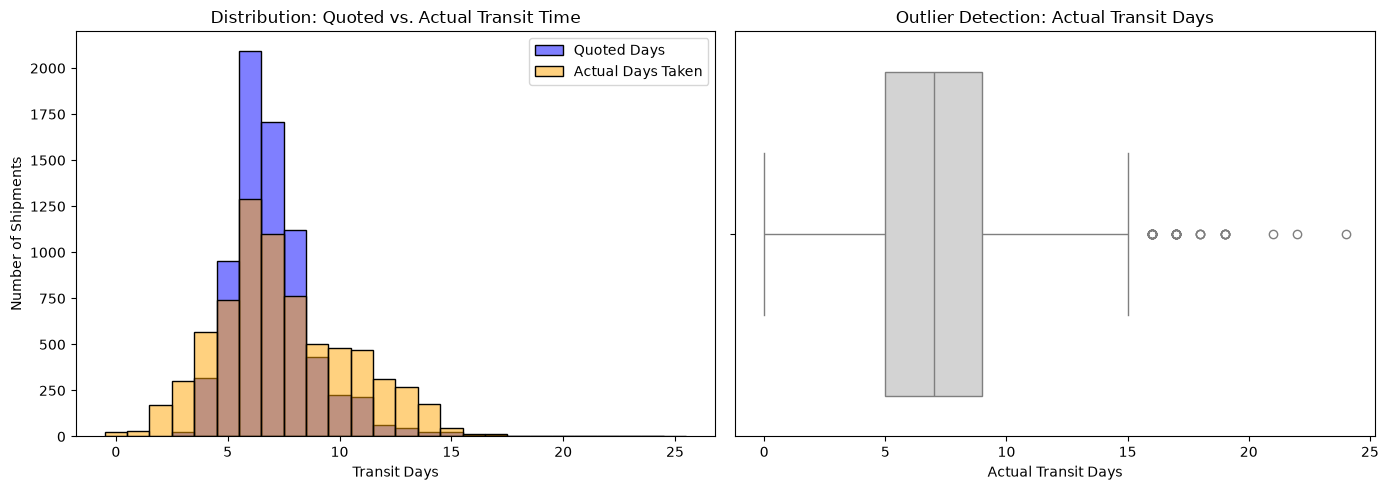


 PART 2: UNSUPERVISED CLUSTERING 

Clustering 9 valid postal codes based on performance...

=== CLUSTER PROFILES (Average metrics per group) ===
            Total_Volume  Delay_Rate  Avg_Actual_Days  Std_Dev_Days  \
Cluster_ID                                                            
0                 2026.5        0.31             7.03          2.54   
1                  479.2        0.57             8.81          3.03   
2                  402.0        0.09             5.20          3.00   
3                  427.0        0.14             7.79          3.95   

            Postal_Code_Count  
Cluster_ID                     
0                           2  
1                           5  
2                           1  
3                           1  

=== POSTAL CODES PER CLUSTER ===

Cluster 0 (2 postal codes):
2009, 4116

Cluster 1 (5 postal codes):
1116, 1300, 1700, 2600, 3019

Cluster 2 (1 postal codes):
2023

Cluster 3 (1 postal codes):
6014


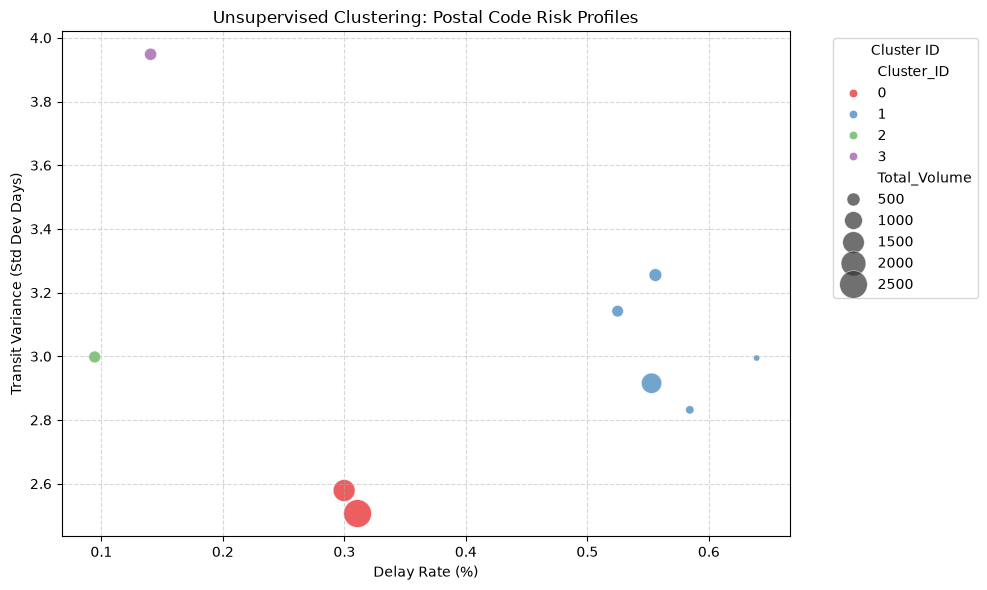

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

# Step 1 : Performs full diagnostics and visualizations on the dataset.

def run_comprehensive_eda(df):
    """
    Performs full diagnostics and visualizations on the logistics dataset to evaluate data health, uncover missing values, and establish baseline performance metrics.

    Parameters
    ----------
    df : pandas.DataFrame
        The historical shipment data (either raw or cleaned) containing columns for transit days, commit compliance, delay reasons, and geographics.

    Returns
    -------
    None
        This function does not return a dataframe. Instead, it directly outputs diagnostic tables to the console and generates matplotlib/seaborn visualizations.
    """

    print("\n" + "="*40)
    print(" PART 1: COMPREHENSIVE EDA ")
    print("="*40 + "\n")

    # 1. Dataset Shape and High-Level Health
    print("=== 1. DATASET SHAPE & HEALTH ===")
    print(f"Total Shipments (Rows): {df.shape[0]}")
    print(f"Total Features (Columns): {df.shape[1]}")

    print("\n=== 2. MISSING VALUES DIAGNOSTIC ===")
    missing_data = df.isnull().sum()
    missing_pct = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

    if missing_df.empty:
        print("No missing values found. Data is perfectly dense.")
    else:
        print("Columns with missing data that require imputation/dropping:")
        print(missing_df.round(2))

    # 3. Target Variable Analysis (Current Network Performance)
    print("\n=== 3. BASELINE PERFORMANCE (TARGET VARIABLE) ===")
    if 'Delivered_in_Commit' in df.columns:
        compliance_counts = df['Delivered_in_Commit'].value_counts()
        compliance_pct = df['Delivered_in_Commit'].value_counts(normalize=True) * 100

        print("Raw On-Time vs. Late Breakdown:")
        for status, count in compliance_counts.items():
            pct = compliance_pct[status]
            label = "On-Time (1)" if status == 1 else "Late/Failed (0)"
            print(f" - {label}: {count} shipments ({pct:.2f}%)")
    else:
        print("Target variable 'Delivered_in_Commit' not found.")

    # 4. Delay Categorization Analysis
    print("\n=== 4. FAILURE BUCKET DISTRIBUTION ===")
    if 'Failure_Bucket' in df.columns:
        top_failures = df['Failure_Bucket'].value_counts().head(5)
        print("Top 5 Reasons for Delay (if recorded):")
        print(top_failures)

    # 5. Geographic Imbalance Analysis (Top Lanes)
    print("\n=== 5. TOP VOLUME ORIGIN/DESTINATION PAIRS ===")
    if 'orig_cntry_cd' in df.columns and 'dest_cntry_cd' in df.columns:
        lane_volume = df.groupby(['orig_cntry_cd', 'dest_cntry_cd']).size().reset_index(name='Volume')
        lane_volume = lane_volume.sort_values(by='Volume', ascending=False).head(5)
        print(lane_volume.to_string(index=False))

    # --- VISUALIZATIONS ---
    print("\nGenerating visual distributions...")

    # Identify the correct actual transit days column (handles raw vs cleaned data)
    actual_col = 'Calculated_Actual_Days' if 'Calculated_Actual_Days' in df.columns else 'Actual_Transit_Days'

    if 'Quoted_Transit_Days' in df.columns and actual_col in df.columns:
        # Sanitize Data specifically for Plotting
        plot_data = df[['Quoted_Transit_Days', actual_col]].apply(pd.to_numeric, errors='coerce').dropna()

        # Set up the figure layout (1 row, 2 columns)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Plot A: Overlapping Histogram
        sns.histplot(data=plot_data, x='Quoted_Transit_Days', color='blue', label='Quoted Days',
                     alpha=0.5, ax=axes[0], binwidth=1, discrete=True)

        sns.histplot(data=plot_data, x=actual_col, color='orange', label='Actual Days Taken',
                     alpha=0.5, ax=axes[0], binwidth=1, discrete=True)

        axes[0].set_title('Distribution: Quoted vs. Actual Transit Time')
        axes[0].set_xlabel('Transit Days')
        axes[0].set_ylabel('Number of Shipments')
        axes[0].legend()

        # Plot B: Boxplot for Outlier Detection
        sns.boxplot(data=plot_data, x=actual_col, ax=axes[1], color='lightgray')
        axes[1].set_title('Outlier Detection: Actual Transit Days')
        axes[1].set_xlabel('Actual Transit Days')

        plt.tight_layout()
        plt.show()

# Step 2: Perform Unsupervised Clustering
    """
    Uses K-Means clustering to automatically group postal codes based on their historical delivery performance, volume, and variance.

        This step is to group destination postal codes based on four dimensions:
        1. Volume: How much freight goes there?
        2. Delay Rate: How often does it fail the SLA?
        3. Average Transit Time: Is it a fast or slow lane generally?
        4. Transit Variance (Standard Deviation): Is it predictable or chaotic?


    Parameters
    ----------
    df : pandas.DataFrame
        The historical shipment dataset. Must contain a commit compliance indicator and actual transit days to calculate performance metrics.
    n_clusters : int, optional (default=4)
        The number of distinct behavioral clusters to form.
        n_clusters=4 clusters to map intuitively to distinct, actionable business strategies:
        - Cluster 0: High-Volume, Highly Stable (Golden Lanes - keep standard quotes)
        - Cluster 1: High-Volume, Chronic Delays (Core Bottlenecks - extend quotes heavily)
        - Cluster 2: Low-Volume, High-Variance (Wildcards - pad quotes for safety)
        - Cluster 3: Low/Med-Volume, Stable (Standard network - safe to quote normally)

    Returns
    -------
    postal_metrics : pandas.DataFrame
        A dataframe grouped by destination postal code ('dest_pstl_cd'). It contains the aggregated feature metrics (Total_Volume, Delay_Rate, Avg_Actual_Days, Std_Dev_Days) and the newly assigned 'Cluster_ID' for each zip code.
    """

def run_postal_clustering(df, n_clusters=4):

    print("\n" + "="*40)
    print(" PART 2: UNSUPERVISED CLUSTERING ")
    print("="*40 + "\n")

    # 1. Feature Engineering for Clustering (Aggregating to Postal Code Level)
    if 'Delivered_in_Commit' in df.columns:
        df['Is_Delayed'] = (df['Delivered_in_Commit'] == 0).astype(int)
    else:
        print("Error: Target variable missing. Cannot calculate delay rates.")
        return None

    actual_col = 'Calculated_Actual_Days' if 'Calculated_Actual_Days' in df.columns else 'Actual_Transit_Days'

    # Group by Destination Postal Code
    postal_metrics = df.groupby('dest_pstl_cd').agg(
        Total_Volume=('Is_Delayed', 'count'),
        Total_Delays=('Is_Delayed', 'sum'),
        Avg_Actual_Days=(actual_col, 'mean'),
        Std_Dev_Days=(actual_col, 'std')
    ).reset_index()

    # Calculate Delay Rate and fill NaN standard deviations
    postal_metrics['Delay_Rate'] = postal_metrics['Total_Delays'] / postal_metrics['Total_Volume']
    postal_metrics['Std_Dev_Days'] = postal_metrics['Std_Dev_Days'].fillna(0)

    # Filter out extreme low-volume noise
    postal_metrics = postal_metrics[postal_metrics['Total_Volume'] >= 5].copy()

    print(f"Clustering {len(postal_metrics)} valid postal codes based on performance...")

    # 2. Preprocessing: Scale the features
    features_to_cluster = ['Total_Volume', 'Delay_Rate', 'Avg_Actual_Days', 'Std_Dev_Days']
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(postal_metrics[features_to_cluster])

    # 3. Apply K-Means Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    postal_metrics['Cluster_ID'] = kmeans.fit_predict(scaled_features)

    # 4. Business Profiling
    cluster_summary = postal_metrics.groupby('Cluster_ID')[features_to_cluster].mean().round(2)
    cluster_summary['Postal_Code_Count'] = postal_metrics['Cluster_ID'].value_counts()

    print("\n=== CLUSTER PROFILES (Average metrics per group) ===")
    print(cluster_summary)

    # This is optional but I decided to add this in to show the postals for each cluster

    # 4.1 Display Postal Codes in each Cluster
    print("\n=== POSTAL CODES PER CLUSTER ===")
    for cluster in sorted(postal_metrics['Cluster_ID'].unique()):
        postals = postal_metrics[postal_metrics['Cluster_ID'] == cluster]['dest_pstl_cd'].tolist()
        print(f"\nCluster {cluster} ({len(postals)} postal codes):")
        # Print as a comma-separated string for readability
        print(", ".join(map(str, postals)))


    # 5. Visualization
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=postal_metrics,
        x='Delay_Rate',
        y='Std_Dev_Days',
        hue='Cluster_ID',
        size='Total_Volume',
        sizes=(20, 400),
        palette='Set1',
        alpha=0.7
    )

    plt.title('Unsupervised Clustering: Postal Code Risk Profiles')
    plt.xlabel('Delay Rate (%)')
    plt.ylabel('Transit Variance (Std Dev Days)')
    plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return postal_metrics


# --- Execution Block ---
if __name__ == "__main__":
    # Define the file name (assuming you are pointing to the cleaned dataset generated earlier)
    file_name = "Cleaned_IEF_Shipments_FY26.csv"

    # Using '..' to step out of the /Notebooks/ folder, then into /Data/Processed/
    data_path = os.path.join("..", "Data", "Processed", file_name)

    print(f"Attempting to load data from: {data_path}")

    try:
        # Load the raw data once
        main_df = pd.read_csv(data_path)

        # 1. Run the EDA Diagnostics & Distributions
        run_comprehensive_eda(main_df)

        # 2. Run the K-Means Clustering Profiling
        clustered_postals_df = run_postal_clustering(main_df, n_clusters=4)

    except FileNotFoundError:
        print(f"\n[ERROR] Could not find the file at: {data_path}")
        print("Please ensure your directory structure looks like this:")
        print("📁 Your_Project_Folder")
        print(" ┣ 📁 Data")
        print(" ┃ ┗ 📁 Processed")
        print(f" ┃   ┗ 📄 {file_name}")
        print(" ┗ 📁 Notebooks")
        print("   ┗ 📄 (Your Jupyter Notebook)")